In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [2]:
df = pd.read_csv('/content/drive/MyDrive/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children      expenses
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.665471     1.094918  13270.422414
std      14.049960     6.098382     1.205493  12110.011240
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4740.287500
50%      39.000000    30.400000     1.000000   9382.030000
75%      51.000000    34.700000     2.000000  16639.915000
max

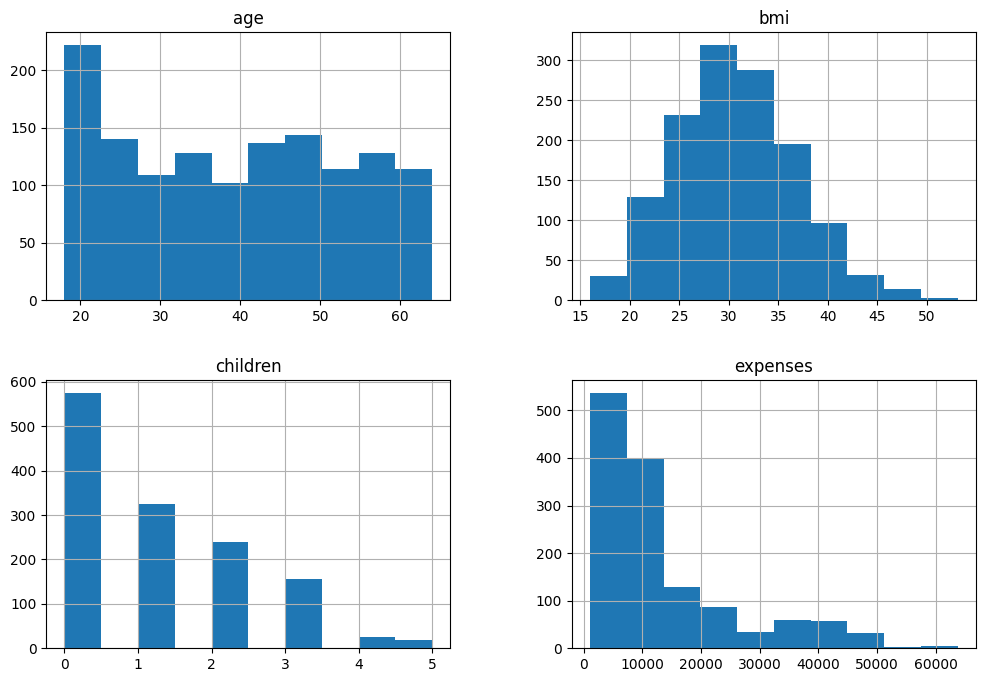

In [3]:
print(df.info())
print(df.describe())

df.hist(figsize=(12,8))
plt.show()

In [4]:
df_encoded = df.copy()

le = LabelEncoder()

for col in ['sex', 'smoker', 'region']:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,0,27.9,0,1,3,16884.92
1,18,1,33.8,1,0,2,1725.55
2,28,1,33.0,3,0,2,4449.46
3,33,1,22.7,0,0,1,21984.47
4,32,1,28.9,0,0,1,3866.86


In [5]:
#Definir variables
X = df_encoded.drop('smoker', axis=1)
y = df_encoded['smoker']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [6]:
#Arbol de decision (Clasificación)
dtc = DecisionTreeClassifier(max_depth=4, random_state=42)
dtc.fit(X_train, y_train)

y_pred_dtc = dtc.predict(X_test)

print("=== Decision Tree Classifier ===")
print(classification_report(y_test, y_pred_dtc))
print(confusion_matrix(y_test, y_pred_dtc))

=== Decision Tree Classifier ===
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       323
           1       0.87      0.97      0.92        79

    accuracy                           0.97       402
   macro avg       0.93      0.97      0.95       402
weighted avg       0.97      0.97      0.97       402

[[311  12]
 [  2  77]]


In [7]:
#Random Forest (Clasificación)
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

y_pred_rfc = rfc.predict(X_test)

print("=== Random Forest Classifier ===")
print(classification_report(y_test, y_pred_rfc))
print(confusion_matrix(y_test, y_pred_rfc))

=== Random Forest Classifier ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       323
           1       0.90      0.96      0.93        79

    accuracy                           0.97       402
   macro avg       0.95      0.97      0.96       402
weighted avg       0.97      0.97      0.97       402

[[315   8]
 [  3  76]]


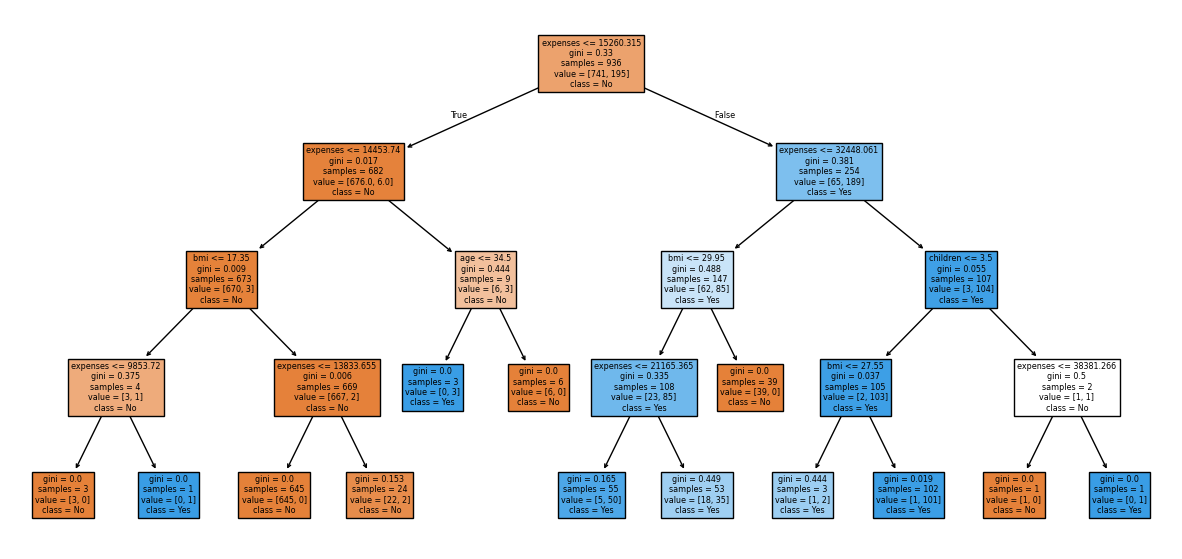

In [8]:
#Visualización del Arbol
plt.figure(figsize=(15,7))
plot_tree(dtc, feature_names=X.columns, class_names=['No','Yes'], filled=True)
plt.show()

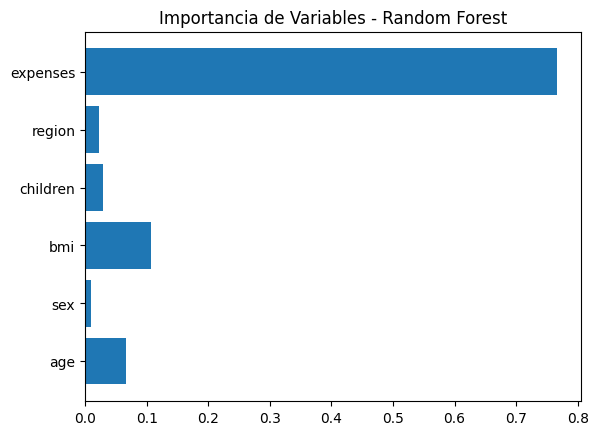

In [9]:
#Importancia de variables (Random Forest)
importances = rfc.feature_importances_

plt.barh(X.columns, importances)
plt.title("Importancia de Variables - Random Forest")
plt.show()

# **PARTE 2: REGRESIÓN-Predecir Expenses**

In [11]:
#Definir variables
X = df_encoded.drop('expenses', axis=1)
y = df_encoded['expenses']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [12]:
#Arboles de decision  regresion
dtr = DecisionTreeRegressor(max_depth=4, random_state=42)
dtr.fit(X_train, y_train)

y_pred_dtr = dtr.predict(X_test)

print("=== Decision Tree Regressor ===")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dtr)))
print("R2:", r2_score(y_test, y_pred_dtr))

=== Decision Tree Regressor ===
RMSE: 4556.508598888072
R2: 0.8584015791661325


In [13]:
#Random Forest (Regresión)
rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(X_train, y_train)

y_pred_rfr = rfr.predict(X_test)

print("=== Random Forest Regressor ===")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rfr)))
print("R2:", r2_score(y_test, y_pred_rfr))

=== Random Forest Regressor ===
RMSE: 4648.39586419345
R2: 0.8526330029715168


# **Comparación visual (Predicciones vs reales)**

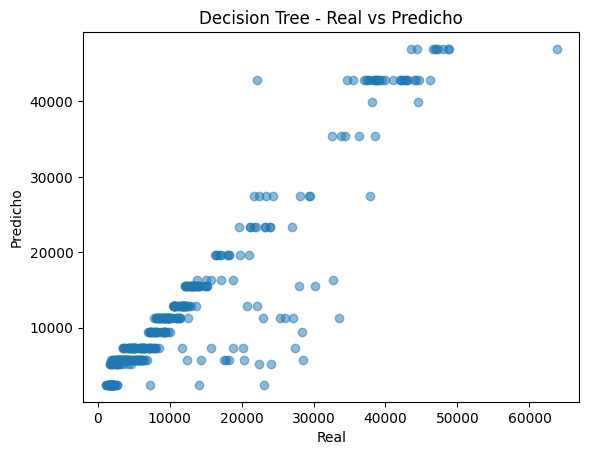

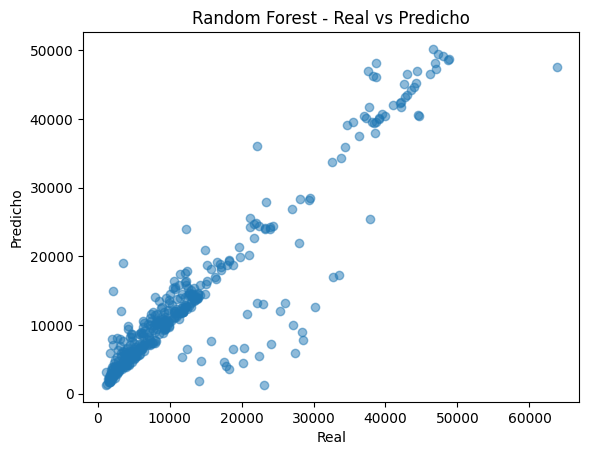

In [14]:
plt.scatter(y_test, y_pred_dtr, alpha=0.5)
plt.title("Decision Tree - Real vs Predicho")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.show()

plt.scatter(y_test, y_pred_rfr, alpha=0.5)
plt.title("Random Forest - Real vs Predicho")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.show()

Random Forest mejora el rendimiento porque combina múltiples árboles
Reduce el overfitting del árbol individual
El árbol de decisión es más interpretable, pero menos preciso
Random Forest logra:
Mejor accuracy en clasificación
Mejor R² y menor RMSE en regresión

# **COMPARACIÓN CON NAIVE BAYES (Clasificación)**

In [19]:
from sklearn.naive_bayes import GaussianNB
#Definir variables
X = df_encoded.drop('smoker', axis=1)
y = df_encoded['smoker']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [20]:
#Entrenar el modelo de Naives Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("=== Naive Bayes (GaussianNB) ===")
print(classification_report(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))

=== Naive Bayes (GaussianNB) ===
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       323
           1       0.82      0.75      0.78        79

    accuracy                           0.92       402
   macro avg       0.88      0.85      0.87       402
weighted avg       0.92      0.92      0.92       402

[[310  13]
 [ 20  59]]


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluar_modelo(nombre, y_true, y_pred):
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

resultados = []

resultados.append(evaluar_modelo("Decision Tree", y_test, y_pred_dtc))
resultados.append(evaluar_modelo("Random Forest", y_test, y_pred_rfc))
resultados.append(evaluar_modelo("Naive Bayes", y_test, y_pred_nb))

df_resultados = pd.DataFrame(resultados)
df_resultados

,Modelo,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.965174,0.865169,0.974684,0.916667
1,Random Forest,0.972637,0.904762,0.962025,0.932515
2,Naive Bayes,0.917910,0.819444,0.746835,0.781457


# **Visualización comparativa**

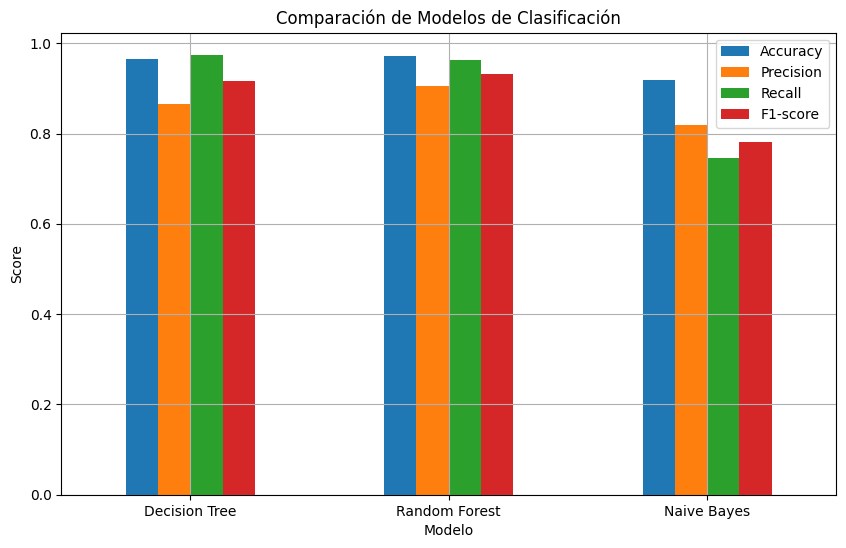

In [22]:
df_resultados.set_index("Modelo").plot(kind="bar", figsize=(10,6))
plt.title("Comparación de Modelos de Clasificación")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid()
plt.show()

*“Se compararon tres modelos de clasificación: Decision Tree, Random Forest y Naive Bayes.
Random Forest obtuvo el mejor desempeño en métricas como accuracy, F1-score y AUC, debido a su capacidad de combinar múltiples árboles y reducir el sobreajuste.
Decision Tree mostró buena interpretabilidad, pero menor capacidad de generalización.
Naive Bayes fue el más rápido, pero su desempeño fue inferior debido a la suposición de independencia entre variables, que no se cumple completamente en este dataset.”***

# **Optimización con GridSearchCV — Random Forest (Clasificación)**

In [23]:
from sklearn.model_selection import GridSearchCV

# Definir parámetros a probar
param_grid_clf = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_clf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_clf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_clf.fit(X_train, y_train)

print("Mejores parámetros (Clasificación):")
print(grid_clf.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros (Clasificación):
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


# **Evaluar mejor modelo (Clasificación)**

In [24]:
best_rfc = grid_clf.best_estimator_

y_pred_best_rfc = best_rfc.predict(X_test)

print("=== Random Forest Optimizado ===")
print(classification_report(y_test, y_pred_best_rfc))
print(confusion_matrix(y_test, y_pred_best_rfc))

=== Random Forest Optimizado ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       323
           1       0.90      0.96      0.93        79

    accuracy                           0.97       402
   macro avg       0.95      0.97      0.96       402
weighted avg       0.97      0.97      0.97       402

[[315   8]
 [  3  76]]
